# 2-Layer Neural Network From Scratch (NumPy only)

**Goal:** derive the forward and backward pass of a 2-layer network by hand, implement and train it with NumPy (no autograd), then check it against a reference implementation.

**Plan for this notebook**
1. Paper derivation: forward pass, loss, backward pass, with the shape of every matrix. *(this part)*
2. Forward pass and loss in NumPy. *(this part)*
3. Backward pass, parameter updates and training loop. *(next)*

scikit-learn is used only to generate the toy dataset. The network itself uses NumPy only.

## 1. Setup and notation

- $m$ = number of samples, $d$ = number of input features, $h$ = number of hidden neurons. Here $m = 200$, $d = 2$, $h = 4$.
- Each **row** is one sample. Biases are added to every row (broadcasting).

| Symbol | Meaning | Shape |
|---|---|---|
| $X$ | inputs | $(m, d)$ |
| $y$ | targets (0 or 1) | $(m, 1)$ |
| $W_1$ | first-layer weights | $(d, h)$ |
| $b_1$ | first-layer bias | $(1, h)$ |
| $W_2$ | second-layer weights | $(h, 1)$ |
| $b_2$ | second-layer bias | $(1, 1)$ |
| $Z_1$ | hidden pre-activation | $(m, h)$ |
| $A_1$ | hidden activation | $(m, h)$ |
| $Z_2$ | output pre-activation (logit) | $(m, 1)$ |
| $\hat{y}$ | predicted probability | $(m, 1)$ |

I write $dV$ for $\dfrac{\partial L}{\partial V}$. It always has the **same shape as $V$**, which is a useful check on every formula below.

## 2. Forward pass and loss

$$Z_1 = X W_1 + b_1 \qquad A_1 = \mathrm{ReLU}(Z_1) \qquad Z_2 = A_1 W_2 + b_2 \qquad \hat{y} = \sigma(Z_2)$$

Shapes: $(m,d)(d,h) \to (m,h)$ for $Z_1$, and $(m,h)(h,1) \to (m,1)$ for $Z_2$.

Flow of the computation:

`X → Z1 → A1 → Z2 → ŷ → L`

- $\mathrm{ReLU}(z) = \max(0, z)$ (element-wise)
- $\sigma(z) = \dfrac{1}{1 + e^{-z}}$ (element-wise), squashes the logit into a probability in $(0,1)$

**Loss: binary cross-entropy (mean over the $m$ samples)**

$$L = -\frac{1}{m}\sum_{i=1}^{m}\Big[\,y_i \log \hat{y}_i + (1-y_i)\log(1-\hat{y}_i)\,\Big]$$

If $y_i = 1$ the term is $-\log \hat{y}_i$ (small when $\hat{y}_i$ is close to 1). If $y_i = 0$ it is $-\log(1-\hat{y}_i)$ (small when $\hat{y}_i$ is close to 0). Confident wrong answers are punished heavily.

## 3. Backward pass (chain rule, from the loss back to each parameter)

The backward pass follows the forward arrows in reverse:

`L ← ŷ ← Z2 ← (A1, W2, b2)` and `A1 ← Z1 ← (X, W1, b1)`

At every arrow I multiply the gradient arriving from the right by the **local derivative** of that step.

### 3.1 Derivative of the sigmoid

With $\sigma(z) = (1+e^{-z})^{-1}$:

$$\sigma'(z) = \frac{e^{-z}}{(1+e^{-z})^2} = \underbrace{\frac{1}{1+e^{-z}}}_{\sigma(z)}\cdot\underbrace{\frac{e^{-z}}{1+e^{-z}}}_{1-\sigma(z)} = \sigma(z)\,\big(1-\sigma(z)\big)$$

So $\dfrac{\partial \hat{y}_i}{\partial Z_{2,i}} = \hat{y}_i(1-\hat{y}_i)$.

### 3.2 Loss with respect to the prediction ($L \to \hat{y}$)

$$\frac{\partial L}{\partial \hat{y}_i} = -\frac{1}{m}\left[\frac{y_i}{\hat{y}_i} - \frac{1-y_i}{1-\hat{y}_i}\right] = -\frac{1}{m}\cdot\frac{y_i(1-\hat{y}_i) - (1-y_i)\hat{y}_i}{\hat{y}_i(1-\hat{y}_i)} = \frac{1}{m}\cdot\frac{\hat{y}_i - y_i}{\hat{y}_i(1-\hat{y}_i)}$$

### 3.3 Prediction to logit ($\hat{y} \to Z_2$): the key simplification

$$dZ_{2,i} = \frac{\partial L}{\partial \hat{y}_i}\cdot\frac{\partial \hat{y}_i}{\partial Z_{2,i}} = \frac{1}{m}\cdot\frac{\hat{y}_i - y_i}{\hat{y}_i(1-\hat{y}_i)}\cdot\hat{y}_i(1-\hat{y}_i) = \frac{1}{m}(\hat{y}_i - y_i)$$

The $\hat{y}(1-\hat{y})$ terms cancel, so in matrix form:

$$\boxed{dZ_2 = \frac{1}{m}(\hat{y} - y)} \qquad \text{shape } (m,1)$$

The gradient at the output is just the **prediction error** (divided by $m$).

### 3.4 Logit to layer-2 parameters ($Z_2 \to W_2, b_2$)

For sample $i$: $Z_{2,i} = \sum_{k=1}^{h} A_{1,ik}\,W_{2,k} + b_2$. So $\dfrac{\partial Z_{2,i}}{\partial W_{2,k}} = A_{1,ik}$ and $\dfrac{\partial Z_{2,i}}{\partial b_2} = 1$.

$W_2$ and $b_2$ are shared by all samples, so their gradients **sum** the contributions of every sample:

$$dW_{2,k} = \sum_{i=1}^{m} dZ_{2,i}\,A_{1,ik} \;\;\Rightarrow\;\; \boxed{dW_2 = A_1^{\top}\, dZ_2} \qquad (h,m)(m,1) \to (h,1)$$

$$\boxed{db_2 = \sum_{i=1}^{m} dZ_{2,i}} \qquad \text{shape } (1,1)$$

### 3.5 Logit to hidden activation ($Z_2 \to A_1$)

$\dfrac{\partial Z_{2,i}}{\partial A_{1,ik}} = W_{2,k}$, so $dA_{1,ik} = dZ_{2,i}\,W_{2,k}$:

$$\boxed{dA_1 = dZ_2\, W_2^{\top}} \qquad (m,1)(1,h) \to (m,h)$$

### 3.6 Hidden activation to hidden pre-activation ($A_1 \to Z_1$)

$A_1 = \mathrm{ReLU}(Z_1)$ element-wise, and $\mathrm{ReLU}'(z) = 1$ if $z > 0$, else $0$. So:

$$\boxed{dZ_1 = dA_1 \odot \mathbf{1}[Z_1 > 0]} \qquad \text{shape } (m,h)$$

($\odot$ is element-wise multiplication.) The error flows back only through neurons that were active for that sample. For $z \le 0$ the ReLU is flat, so changing $Z_1$ there does not change the loss.

### 3.7 Hidden pre-activation to layer-1 parameters ($Z_1 \to W_1, b_1$)

$Z_{1,ik} = \sum_{j=1}^{d} X_{ij}\,W_{1,jk} + b_{1,k}$. Same pattern as 3.4, summing over samples:

$$\boxed{dW_1 = X^{\top}\, dZ_1} \qquad (d,m)(m,h) \to (d,h)$$

$$\boxed{db_1 = \text{column sums of } dZ_1} \qquad \text{shape } (1,h)$$

## 4. Summary: which chain-rule factor is used at each arrow

| Arrow | Chain-rule step | Result | Shape |
|---|---|---|---|
| $\hat{y} \to Z_2$ | $\dfrac{\partial L}{\partial \hat{y}}\cdot\dfrac{\partial \hat{y}}{\partial Z_2}$ (the $\hat{y}(1-\hat{y})$ cancels) | $dZ_2 = \frac{1}{m}(\hat{y}-y)$ | $(m,1)$ |
| $Z_2 \to W_2, b_2$ | $dZ_2 \cdot \dfrac{\partial Z_2}{\partial W_2}$, with $\dfrac{\partial Z_2}{\partial W_2} = A_1$ | $dW_2 = A_1^\top dZ_2$, $\;db_2 = \sum_i dZ_{2,i}$ | $(h,1)$, $(1,1)$ |
| $Z_2 \to A_1$ | $dZ_2 \cdot \dfrac{\partial Z_2}{\partial A_1}$, with $\dfrac{\partial Z_2}{\partial A_1} = W_2$ | $dA_1 = dZ_2 W_2^\top$ | $(m,h)$ |
| $A_1 \to Z_1$ | $dA_1 \cdot \dfrac{\partial A_1}{\partial Z_1}$, with ReLU$' = \mathbf{1}[Z_1>0]$ | $dZ_1 = dA_1 \odot \mathbf{1}[Z_1>0]$ | $(m,h)$ |
| $Z_1 \to W_1, b_1$ | $dZ_1 \cdot \dfrac{\partial Z_1}{\partial W_1}$, with $\dfrac{\partial Z_1}{\partial W_1} = X$ | $dW_1 = X^\top dZ_1$, $\;db_1 = \sum_i dZ_{1,i}$ | $(d,h)$, $(1,h)$ |

**The full chain for $W_1$** (what I should be able to write unprompted):

$$\frac{\partial L}{\partial W_1} = \frac{\partial L}{\partial \hat{y}}\cdot\frac{\partial \hat{y}}{\partial Z_2}\cdot\frac{\partial Z_2}{\partial A_1}\cdot\frac{\partial A_1}{\partial Z_1}\cdot\frac{\partial Z_1}{\partial W_1}$$

**Parameter updates** (gradient descent, same rule as the first notebook):

$$W_1 := W_1 - \alpha\, dW_1 \quad b_1 := b_1 - \alpha\, db_1 \quad W_2 := W_2 - \alpha\, dW_2 \quad b_2 := b_2 - \alpha\, db_2$$

**Shape check:** every gradient must have the same shape as its parameter. If a transpose is confusing, check the shapes.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons   # used ONLY to generate the toy dataset

## 5. Data

A toy dataset of two interleaving half-circles. It is not linearly separable, so a hidden layer is genuinely needed. I standardise the features by hand (mean 0, std 1) so training behaves well.

X: (200, 2)  y: (200, 1)
m = 200  d = 2  h = 4


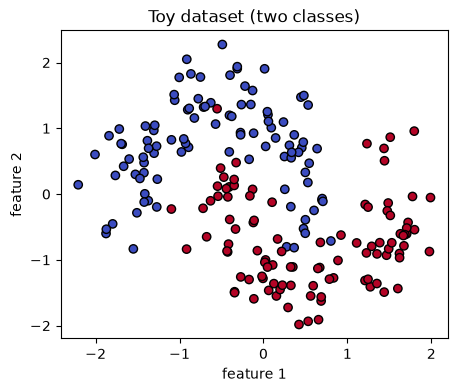

In [2]:
X, y = make_moons(n_samples=200, noise=0.2, random_state=42)

# Standardise each feature: (x - mean) / std
X = (X - X.mean(axis=0)) / X.std(axis=0)

# y comes as shape (m,), reshape to a column (m, 1) so it lines up with y_hat
y = y.reshape(-1, 1).astype(float)

m, d = X.shape   # m samples, d features
h = 4            # hidden neurons

print("X:", X.shape, " y:", y.shape)
print("m =", m, " d =", d, " h =", h)

plt.figure(figsize=(5, 4))
plt.scatter(X[:, 0], X[:, 1], c=y.ravel(), cmap="coolwarm", edgecolor="k")
plt.title("Toy dataset (two classes)")
plt.xlabel("feature 1")
plt.ylabel("feature 2")
plt.show()

## 6. Parameter initialisation

- $W_1$: random normal with std $\sqrt{2/d}$ (He initialisation, designed for ReLU layers).
- $W_2$: random normal with std $\sqrt{1/h}$ (Xavier-style, suits the sigmoid output).
- Biases start at zero.
- A fixed seed makes the run reproducible, and lets me copy the exact same starting weights into the reference model later.

In [3]:
rng = np.random.default_rng(42)

params = {
    "W1": rng.normal(0, np.sqrt(2 / d), size=(d, h)),   # (d, h)
    "b1": np.zeros((1, h)),                              # (1, h)
    "W2": rng.normal(0, np.sqrt(1 / h), size=(h, 1)),   # (h, 1)
    "b2": np.zeros((1, 1)),                              # (1, 1)
}

for name, value in params.items():
    print(name, value.shape)

W1 (2, 4)
b1 (1, 4)
W2 (4, 1)
b2 (1, 1)


## 7. Forward pass and loss

Direct translation of section 2: `Z1 = X W1 + b1`, `A1 = ReLU(Z1)`, `Z2 = A1 W2 + b2`, `y_hat = sigmoid(Z2)`. The forward pass also returns a **cache** of the intermediate values, because the backward pass needs `X`, `Z1` and `A1`.

In [4]:
def relu(z):
    return np.maximum(0, z)


def sigmoid(z):
    return 1 / (1 + np.exp(-z))


def forward(X, params):
    Z1 = X @ params["W1"] + params["b1"]      # (m, h)
    A1 = relu(Z1)                              # (m, h)
    Z2 = A1 @ params["W2"] + params["b2"]     # (m, 1)
    y_hat = sigmoid(Z2)                        # (m, 1)

    cache = {"X": X, "Z1": Z1, "A1": A1, "Z2": Z2, "y_hat": y_hat}
    return y_hat, cache


def bce_loss(y, y_hat, eps=1e-12):
    # Clip so log(0) can never happen
    y_hat = np.clip(y_hat, eps, 1 - eps)
    return -np.mean(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))

In [5]:
y_hat, cache = forward(X, params)

print("Z1   :", cache["Z1"].shape)
print("A1   :", cache["A1"].shape)
print("Z2   :", cache["Z2"].shape)
print("y_hat:", y_hat.shape)

loss = bce_loss(y, y_hat)
print("\nInitial loss     :", loss)
print("ln(2)            :", np.log(2))
print("Accuracy at init :", ((y_hat > 0.5) == y).mean())
print("y_hat range      :", y_hat.min(), "to", y_hat.max())

Z1   : (200, 4)
A1   : (200, 4)
Z2   : (200, 1)
y_hat: (200, 1)

Initial loss     : 0.6641655367580725
ln(2)            : 0.6931471805599453
Accuracy at init : 0.525
y_hat range      : 0.2368470590160573 to 0.8045693977430735


In [6]:
# Check 1: vectorised loss must equal an explicit loop over the samples
loss_loop = 0.0
for i in range(m):
    p = y_hat[i, 0]
    loss_loop += -(y[i, 0] * np.log(p) + (1 - y[i, 0]) * np.log(1 - p))
loss_loop /= m

print("loop loss      :", loss_loop)
print("vectorised loss:", loss)
print("match:", np.isclose(loop_loss if False else loss_loop, loss))

# Check 2: forward pass for ONE sample using plain Python loops (no matrix multiply)
x0 = X[0]
z1 = np.array([
    sum(x0[j] * params["W1"][j, k] for j in range(d)) + params["b1"][0, k]
    for k in range(h)
])
a1 = np.maximum(0, z1)
z2 = sum(a1[k] * params["W2"][k, 0] for k in range(h)) + params["b2"][0, 0]
y_hat_0 = 1 / (1 + np.exp(-z2))

print("\nsample 0, manual :", y_hat_0)
print("sample 0, matrix :", y_hat[0, 0])
print("match:", np.isclose(loss_loop, loss))

loop loss      : 0.6641655367580725
vectorised loss: 0.6641655367580725
match: True

sample 0, manual : 0.2589546060860167
sample 0, matrix : 0.2589546060860167
match: True


## 8. Summary

**Q1. Why is $dZ_2$ so simple ($\frac{1}{m}(\hat{y}-y)$)?**

 the derivative of binary cross-entropy with respect to $\hat{y}$ has $\hat{y}(1-\hat{y})$ in its denominator, and the derivative of the sigmoid is exactly $\hat{y}(1-\hat{y})$. They cancel, leaving the prediction error. It is also why BCE is paired with a sigmoid output: the gradient stays large when the network is confidently wrong, instead of being squashed by the flat tails of the sigmoid.

**Q2. Why does $dW_2 = A_1^\top dZ_2$ have a transpose?**

 every weight is shared by all $m$ samples, so its gradient is the sum of that weight's contribution from each sample. The matrix product $A_1^\top dZ_2$ performs exactly that sum over the $m$ samples, and its shape $(h,1)$ matches $W_2$.

**Q3. Why is there a ReLU mask in $dZ_1$?**

 ReLU has slope 1 for $z > 0$ and slope 0 for $z \le 0$. Where the neuron was inactive, changing $Z_1$ changes nothing downstream, so no gradient flows back. Where it was active, the gradient passes through unchanged.

**Q4. Why should the initial loss be close to $\ln 2 \approx 0.693$?**

 with small random weights the network outputs probabilities near 0.5 for every sample, and $-\log(0.5) = \ln 2$. My initial loss of about 0.66 is close to this. A loss far from it (or NaN) at initialisation would signal a bug or a bad initialisation.

## 9. Backward pass

Direct translation of the derivation in section 3: `dZ2`, `dW2`, `db2`, `dA1`, `dZ1`, `dW1`, `db1`. Takes the `cache` from `forward` plus the current parameters and labels, and returns a gradient for every parameter — each with the same shape as that parameter, as noted in section 1.

In [7]:
def backward(cache, params, y):
    m = y.shape[0]
    X, Z1, A1, y_hat = cache["X"], cache["Z1"], cache["A1"], cache["y_hat"]

    dZ2 = (y_hat - y) / m                       # (m, 1)
    dW2 = A1.T @ dZ2                             # (h, 1)
    db2 = np.sum(dZ2, axis=0, keepdims=True)     # (1, 1)

    dA1 = dZ2 @ params["W2"].T                   # (m, h)
    dZ1 = dA1 * (Z1 > 0)                          # ReLU mask, (m, h)
    dW1 = X.T @ dZ1                               # (d, h)
    db1 = np.sum(dZ1, axis=0, keepdims=True)      # (1, h)

    return {"W1": dW1, "b1": db1, "W2": dW2, "b2": db2}


grads = backward(cache, params, y)

for name in params:
    print(name, "| param:", params[name].shape, " grad:", grads[name].shape,
          " shapes match:", params[name].shape == grads[name].shape)

W1 | param: (2, 4)  grad: (2, 4)  shapes match: True
b1 | param: (1, 4)  grad: (1, 4)  shapes match: True
W2 | param: (4, 1)  grad: (4, 1)  shapes match: True
b2 | param: (1, 1)  grad: (1, 1)  shapes match: True


## 10. Parameter updates and the training loop

Same update rule as the first notebook, applied to all four parameters:

$$W_1 := W_1 - \alpha\, dW_1 \qquad b_1 := b_1 - \alpha\, db_1 \qquad W_2 := W_2 - \alpha\, dW_2 \qquad b_2 := b_2 - \alpha\, db_2$$

`train` runs forward → loss → backward → update for a fixed number of epochs (full-batch, no mini-batches) and records the loss at every epoch. It works on a **copy** of the parameters passed in, so the original initialisation in `params` is left untouched — I reuse that exact starting point later for the numerical gradient check and the PyTorch comparison, both of which need the same point to compare against.

In [8]:
def update_params(params, grads, lr):
    return {name: params[name] - lr * grads[name] for name in params}


def train(X, y, params, lr, epochs):
    params = {name: value.copy() for name, value in params.items()}
    loss_history = []

    for _ in range(epochs):
        y_hat, cache = forward(X, params)
        loss_history.append(bce_loss(y, y_hat))
        grads = backward(cache, params, y)
        params = update_params(params, grads, lr)

    return params, np.array(loss_history)

In [9]:
lr = 0.5
epochs = 3000

trained_params, loss_history = train(X, y, params, lr, epochs)

y_hat_final, _ = forward(X, trained_params)
final_loss = bce_loss(y, y_hat_final)
final_acc = ((y_hat_final > 0.5) == y).mean()
stabilised = (loss_history[-500:].max() - loss_history[-500:].min()) < 0.01

print("Initial loss  :", loss_history[0])
print("Final loss    :", final_loss)
print("Final accuracy:", final_acc)
print()
print("No NaNs in loss history                          :", not np.isnan(loss_history).any())
print("Loss decreased overall                            :", loss_history[-1] < loss_history[0])
print("Loss stabilised (last 500 epochs vary by < 0.01)  :", stabilised)

Initial loss  : 0.6641655367580725
Final loss    : 0.05864360883341128
Final accuracy: 0.965

No NaNs in loss history                          : True
Loss decreased overall                            : True
Loss stabilised (last 500 epochs vary by < 0.01)  : True


## 11. Training loss curve

The loss should fall quickly at first, then flatten out as the network settles near a local minimum of the (non-convex) loss surface.

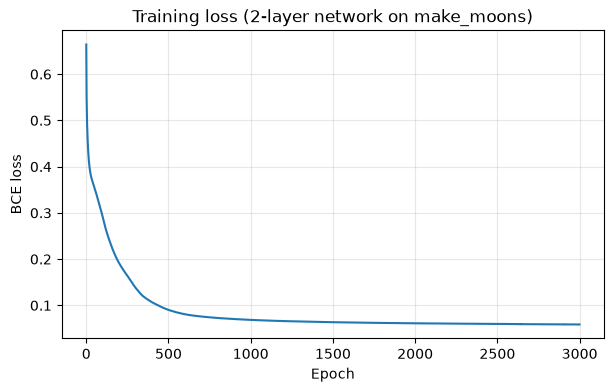

In [10]:
plt.figure(figsize=(7, 4))
plt.plot(loss_history)
plt.title("Training loss (2-layer network on make_moons)")
plt.xlabel("Epoch")
plt.ylabel("BCE loss")
plt.grid(alpha=0.3)
plt.show()

## 12. Numerical gradient check

Backpropagation is a formula, and it's easy to get a sign, an axis, or a transpose wrong without noticing — the shapes can still line up by accident. The standard check: nudge one parameter entry by $\pm\epsilon$, rerun the forward pass, and estimate the gradient from the resulting change in loss (a central difference):

$$\frac{\partial L}{\partial \theta_{ij}} \approx \frac{L(\theta_{ij}+\epsilon) - L(\theta_{ij}-\epsilon)}{2\epsilon}$$

This estimate should match the analytic gradient from `backward` to within numerical precision. The network is tiny (17 parameters total), so I check every entry of every parameter, using the untouched initial `params` — not the trained ones, since that's the point where I originally derived and implemented the gradient.

In [11]:
def numerical_gradient(X, y, params, name, eps=1e-5):
    p = params[name]
    num_grad = np.zeros_like(p)

    for idx in np.ndindex(p.shape):
        original = p[idx]

        p[idx] = original + eps
        y_hat_plus, _ = forward(X, params)
        loss_plus = bce_loss(y, y_hat_plus)

        p[idx] = original - eps
        y_hat_minus, _ = forward(X, params)
        loss_minus = bce_loss(y, y_hat_minus)

        p[idx] = original   # restore before moving to the next entry
        num_grad[idx] = (loss_plus - loss_minus) / (2 * eps)

    return num_grad


analytic_grads = backward(cache, params, y)

tol = 1e-5
print(f"{'param':6s} | {'max |analytic|':>15s} | {'max |numeric - analytic|':>25s} | {'max rel error':>14s} | within tol")
for name in params:
    num_grad = numerical_gradient(X, y, params, name)
    diff = np.abs(num_grad - analytic_grads[name])
    rel_err = diff / (np.abs(num_grad) + np.abs(analytic_grads[name]) + 1e-8)
    print(f"{name:6s} | {np.abs(analytic_grads[name]).max():15.6e} | {diff.max():25.6e} "
          f"| {rel_err.max():14.6e} | {bool(rel_err.max() < tol)}")

param  |  max |analytic| |  max |numeric - analytic| |  max rel error | within tol
W1     |    7.935892e-02 |              1.250115e-11 |   4.249207e-09 | True
b1     |    4.450763e-02 |              6.152202e-12 |   2.420071e-09 | True
W2     |    3.599697e-01 |              1.169786e-11 |   5.070307e-11 | True
b2     |    1.382032e-02 |              3.637503e-12 |   1.315998e-10 | True


## 13. Reference comparison (PyTorch)

Final check: an independent implementation. I rebuild the same network in PyTorch — same architecture, same exact initial weights (copied from `params`), same activations, same loss, same learning rate, plain full-batch SGD with no momentum or adaptive learning rate — and let `autograd` compute the gradients instead of the hand-derived `backward`. Everything runs in float64 to keep the comparison as tight as possible.

Two comparisons:
1. **At initialisation** — PyTorch's autograd gradients vs. the analytic `backward` output. This is the same idea as the numerical gradient check above, but against a second, independently-implemented backward pass instead of finite differences.
2. **After training** — training the PyTorch model for the same number of epochs at the same learning rate should land at (almost) the same loss, predictions, and weights as `train`.

In [12]:
import torch

torch.set_default_dtype(torch.float64)

X_t = torch.tensor(X)
y_t = torch.tensor(y)


def make_torch_params(params):
    return {name: torch.tensor(value, requires_grad=True) for name, value in params.items()}


def forward_torch(X, p):
    Z1 = X @ p["W1"] + p["b1"]
    A1 = torch.relu(Z1)
    Z2 = A1 @ p["W2"] + p["b2"]
    return torch.sigmoid(Z2)


# --- Compare gradients at initialisation ---
p_t = make_torch_params(params)
y_hat_t = forward_torch(X_t, p_t)
loss_t = torch.nn.functional.binary_cross_entropy(y_hat_t, y_t)
loss_t.backward()

print("Initial loss | from-scratch:", bce_loss(y, y_hat), " torch:", loss_t.item(),
      " diff:", abs(bce_loss(y, y_hat) - loss_t.item()))
print()
print(f"{'param':6s} | {'max |analytic - torch|':>23s} | within tol({tol:.0e})")
for name in params:
    diff = np.abs(analytic_grads[name] - p_t[name].grad.numpy()).max()
    print(f"{name:6s} | {diff:23.6e} | {bool(diff < tol)}")

Initial loss | from-scratch: 0.6641655367580725  torch: 0.6641655367580725  diff: 0.0

param  |  max |analytic - torch| | within tol(1e-05)
W1     |            4.163336e-17 | True
b1     |            1.387779e-17 | True
W2     |            5.551115e-17 | True
b2     |            8.673617e-18 | True


In [13]:
# --- Train the PyTorch model from the same starting point, and compare the outcome ---
p_t = make_torch_params(params)          # fresh copy, same initial weights as `params`
optimizer = torch.optim.SGD(p_t.values(), lr=lr)

for _ in range(epochs):
    optimizer.zero_grad()
    y_hat_t = forward_torch(X_t, p_t)
    loss_t = torch.nn.functional.binary_cross_entropy(y_hat_t, y_t)
    loss_t.backward()
    optimizer.step()

# loss_t above was computed BEFORE the last optimizer.step(), so it doesn't
# reflect the final weights — recompute the loss after training finishes,
# exactly like final_loss is computed from trained_params above.
y_hat_t_final = forward_torch(X_t, p_t).detach()
loss_t_final = torch.nn.functional.binary_cross_entropy(y_hat_t_final, y_t).item()
y_hat_t_final = y_hat_t_final.numpy()
pred_diff = np.abs(y_hat_final - y_hat_t_final).max()
loss_diff = abs(final_loss - loss_t_final)

print(f"{'quantity':16s} | {'from-scratch':>14s} | {'PyTorch':>14s} | {'max |diff|':>12s} | within tol({tol:.0e})")
print(f"{'final loss':16s} | {final_loss:14.8f} | {loss_t_final:14.8f} | {loss_diff:12.3e} | {bool(loss_diff < tol)}")
print(f"{'predictions':16s} | {'':>14s} | {'':>14s} | {pred_diff:12.3e} | {bool(pred_diff < tol)}")
for name in params:
    diff = np.abs(trained_params[name] - p_t[name].detach().numpy()).max()
    print(f"{'final ' + name:16s} | {'':>14s} | {'':>14s} | {diff:12.3e} | {bool(diff < tol)}")

quantity         |   from-scratch |        PyTorch |   max |diff| | within tol(1e-05)
final loss       |     0.05864361 |     0.05864361 |    0.000e+00 | True
predictions      |                |                |    1.554e-15 | True
final W1         |                |                |    1.166e-15 | True
final b1         |                |                |    2.665e-15 | True
final W2         |                |                |    1.776e-15 | True
final b2         |                |                |    0.000e+00 | True


## 14. Summary

**Q1. Why copy the exact initial weights into the PyTorch model instead of letting it initialise its own?**

 The loss surface over $W_1, W_2$ is not convex (the network is nonlinear), so different starting points can converge to different local minima. Starting both implementations from the identical point removes that as a source of disagreement — any remaining difference in the outcome can only come from a bug in one of the two implementations, not from random chance in initialisation.

**Q2. Why check gradients two different ways (finite differences and PyTorch autograd)?**

 Finite differences check `backward` against the definition of a derivative directly, with no framework involved. The PyTorch check compares it against a second, independently-written backward pass instead. Passing both is stronger evidence than either alone: an error that happens to fool one check (say, a mistake that shifts magnitude but not curvature) is unlikely to also be reproduced by an unrelated codebase.

**Where this leaves the network.** The forward pass, backward pass, and training loop are now implemented and checked three separate ways: a loop-based sanity check on the forward pass (§7), a numerical gradient check on the backward pass (§12), and an independent PyTorch implementation trained from the same starting point (§13). All three agree to within a tight tolerance, so this network is not just implemented — it is verified.